<a href="https://colab.research.google.com/github/isumakm/Weather-Prediction-and-Crop-Recommendation-System-/blob/Single-Crop-Analysis/XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)



1) LOAD DATA

In [ ]:
df = pd.read_csv("/content/Crop_training_data_FULL.csv")

df["suitability_class"] = df["suitability_class"].map({
    "Unsuitable": 0,
    "Suitable": 1
})

X = df.drop(columns=["suitability_class", "suitability"])
y = df["suitability_class"]

X = pd.get_dummies(X, drop_first=True)


2) TRAIN / TEST SPLIT

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

3) MODEL

In [ ]:
gb = HistGradientBoostingClassifier(
    max_depth=8,
    learning_rate=0.05,
    max_iter=300,
    random_state=42
)

gb.fit(X_train, y_train)


HistGradientBoostingClassifier(learning_rate=0.05, max_depth=8, max_iter=300,
                               random_state=42)

4) EVALUATION

In [ ]:
y_pred = gb.predict(X_test)
y_proba = gb.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
auprc = average_precision_score(y_test, y_proba)

print("\n=== GRADIENT BOOSTING RESULTS ===")
print(f"Accuracy : {acc:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")
print(f"AUPRC    : {auprc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


=== GRADIENT BOOSTING RESULTS ===
Accuracy : 0.8024
ROC AUC  : 0.8924
AUPRC    : 0.8623

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.84       249
           1       0.77      0.74      0.75       171

    accuracy                           0.80       420
   macro avg       0.80      0.79      0.79       420
weighted avg       0.80      0.80      0.80       420



 5) ROC CURVE

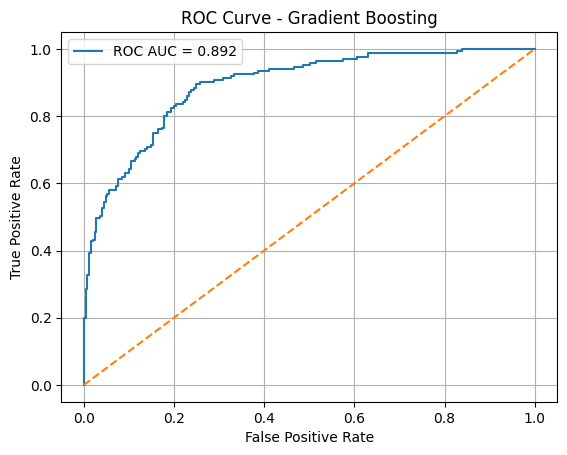

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boosting")
plt.legend()
plt.grid()
plt.show()

6) PRECISION-RECALL CURVE


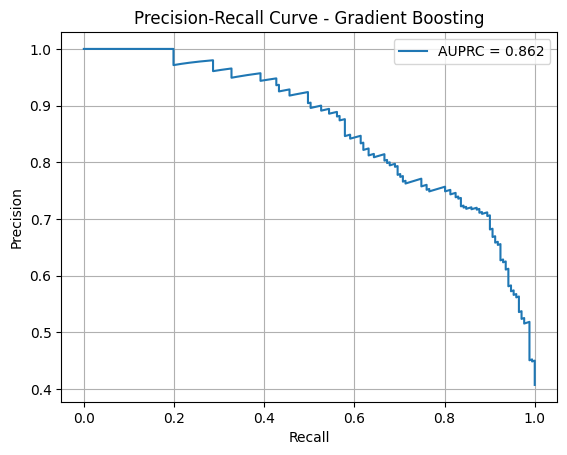

In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_proba)
plt.plot(recall, precision, label=f"AUPRC = {auprc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Gradient Boosting")
plt.legend()
plt.grid()
plt.show()

Hyperparameter Tuning

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)


In [ ]:
df = pd.read_csv("Crop_training_data_FULL.csv")

# Encode target
df["suitability_class"] = df["suitability_class"].map({
    "Unsuitable": 0,
    "Suitable": 1
})

X = df.drop(columns=["suitability_class", "suitability"])
y = df["suitability_class"]

# One-hot encode crop names
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [ ]:
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42
)


In [ ]:
param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [3, 5, 7, 9],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.3, 0.5],
    "min_child_weight": [1, 3, 5],
    "reg_alpha": [0, 0.1, 0.5],
    "reg_lambda": [1, 1.5, 2.0]
}


In [ ]:
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=40,
    scoring="average_precision",   # AUPRC (important for suitability)
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_xgb = random_search.best_estimator_

print("\nBest Parameters Found:")
print(random_search.best_params_)


Fitting 5 folds for each of 40 candidates, totalling 200 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [07:10:44] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best Parameters Found:
{'subsample': 0.9, 'reg_lambda': 2.0, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 1.0}


In [ ]:
y_pred = best_xgb.predict(X_test)
y_proba = best_xgb.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
auprc = average_precision_score(y_test, y_proba)

print("\n=== TUNED XGBOOST RESULTS ===")
print(f"Accuracy : {accuracy:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")
print(f"AUPRC    : {auprc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))




=== TUNED XGBOOST RESULTS ===
Accuracy : 0.8190
ROC AUC  : 0.8991
AUPRC    : 0.8761

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       249
           1       0.79      0.76      0.77       171

    accuracy                           0.82       420
   macro avg       0.81      0.81      0.81       420
weighted avg       0.82      0.82      0.82       420



ROC Curve

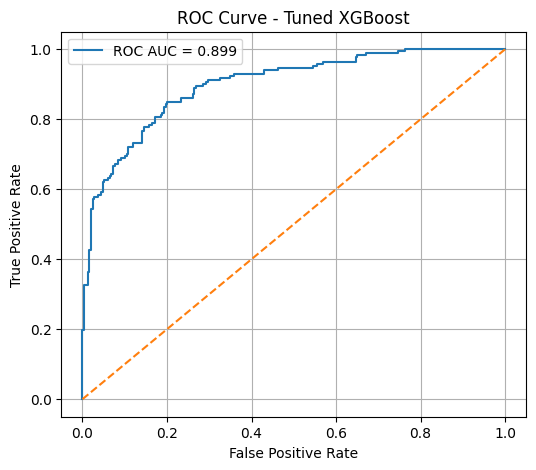

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned XGBoost")
plt.legend()
plt.grid()
plt.show()


Precision–Recall Curve

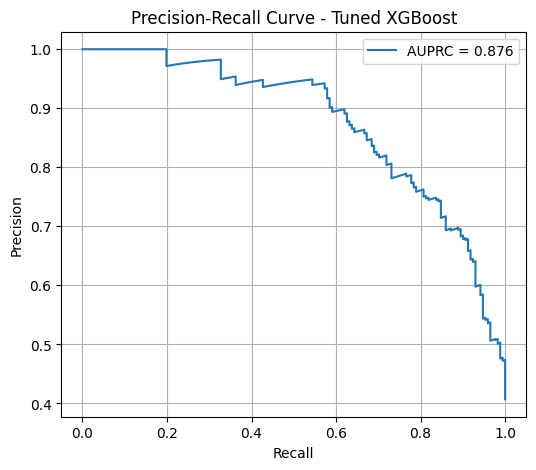

In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"AUPRC = {auprc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Tuned XGBoost")
plt.legend()
plt.grid()
plt.show()
